# 📈 Module 1.1 — Financial Returns
### *From Theory to Real-World Trading with Python*

---

**Course:** Capital Markets Recap — Level 1: Foundations  
**Prerequisites:** Basic algebra, familiarity with financial markets  
**Tools:** `yfinance`, `pandas`, `numpy`, `matplotlib`

---

## What This Module Covers

Before you can evaluate any investment, you need to speak the language of **returns** — how much did an asset gain or lose, and over what period?

This module covers:
1. **Simple (arithmetic) returns** — the basic building block
2. **Log returns** — used heavily in quantitative finance
3. **Dividend-adjusted returns** — what you *actually* earn as an investor
4. **Annualizing returns** — comparing investments on a common scale
5. **Compound interest** — the engine behind long-term wealth

Each concept is connected to a real-world trading use case.

---
## 0. Setup — Load Libraries & Download Data

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [3]:
# ── Download price data ──────────────────────────────────────────────────────
# We'll use Apple (AAPL) as our main example throughout this module.
# yfinance's auto_adjust=True applies stock splits automatically.
# actions=True downloads dividend history alongside prices.

TICKER = 'AAPL'
START  = '2020-01-01'
END    = '2024-12-31'

# Download OHLCV + dividends
raw = yf.download(TICKER, start=START, end=END, auto_adjust=False, actions=True, progress=False)

# Keep only Close price and Dividends
data = raw[['Close', 'Dividends']].copy()
data.columns = ['close', 'dividends']
data.index = pd.to_datetime(data.index)

print(f"Downloaded {len(data)} trading days of {TICKER} data")
print(f"Date range: {data.index[0].date()} → {data.index[-1].date()}")
data.head()

Downloaded 1257 trading days of AAPL data
Date range: 2020-01-02 → 2024-12-30


,close,dividends
Date,,
2020-01-02,75.087502,0.0
2020-01-03,74.357498,0.0
2020-01-06,74.949997,0.0
2020-01-07,74.597504,0.0
2020-01-08,75.797501,0.0


---
## 1. Simple (Arithmetic) Returns

### Theory

The **simple return** (also called *arithmetic return* or *holding period return*) measures the percentage change in price between two periods:

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1
$$

Where:
- $P_t$ = price at time $t$ (today)
- $P_{t-1}$ = price at time $t-1$ (yesterday)
- $R_t$ = return over that period

### When traders use it
Simple returns are used when:
- Calculating **portfolio returns** (weighted average of individual simple returns)
- Reporting **performance** to clients (clear, intuitive interpretation)
- Backtesting strategies over **short holding periods**

> 💡 **Your notes' example:** You had Apple stock data for 2003-2004. The return from 09/04 to 12/03 was:  
> $R = (27.24 + 0.08 - 27.37) / 27.37 = -0.18\%$  
> This is exactly the formula above — let's replicate this logic on modern data.

In [5]:
# ── 1a. Compute daily simple returns ────────────────────────────────────────
# pandas .pct_change() is the standard way to compute period-over-period returns

data['simple_return'] = data['close'].pct_change()

# Show the first few returns
print("First 5 trading days with returns:")
print(data[['close', 'simple_return']].dropna().head())

print(f"\nAverage daily simple return : {data['simple_return'].mean()*100:.4f}%")
print(f"Std dev of daily returns    : {data['simple_return'].std()*100:.4f}%")

First 5 trading days with returns:
                close  simple_return
Date                                
2020-01-03  74.357498      -0.009722
2020-01-06  74.949997       0.007968
2020-01-07  74.597504      -0.004703
2020-01-08  75.797501       0.016086
2020-01-09  77.407501       0.021241

Average daily simple return : 0.1164%
Std dev of daily returns    : 1.9964%


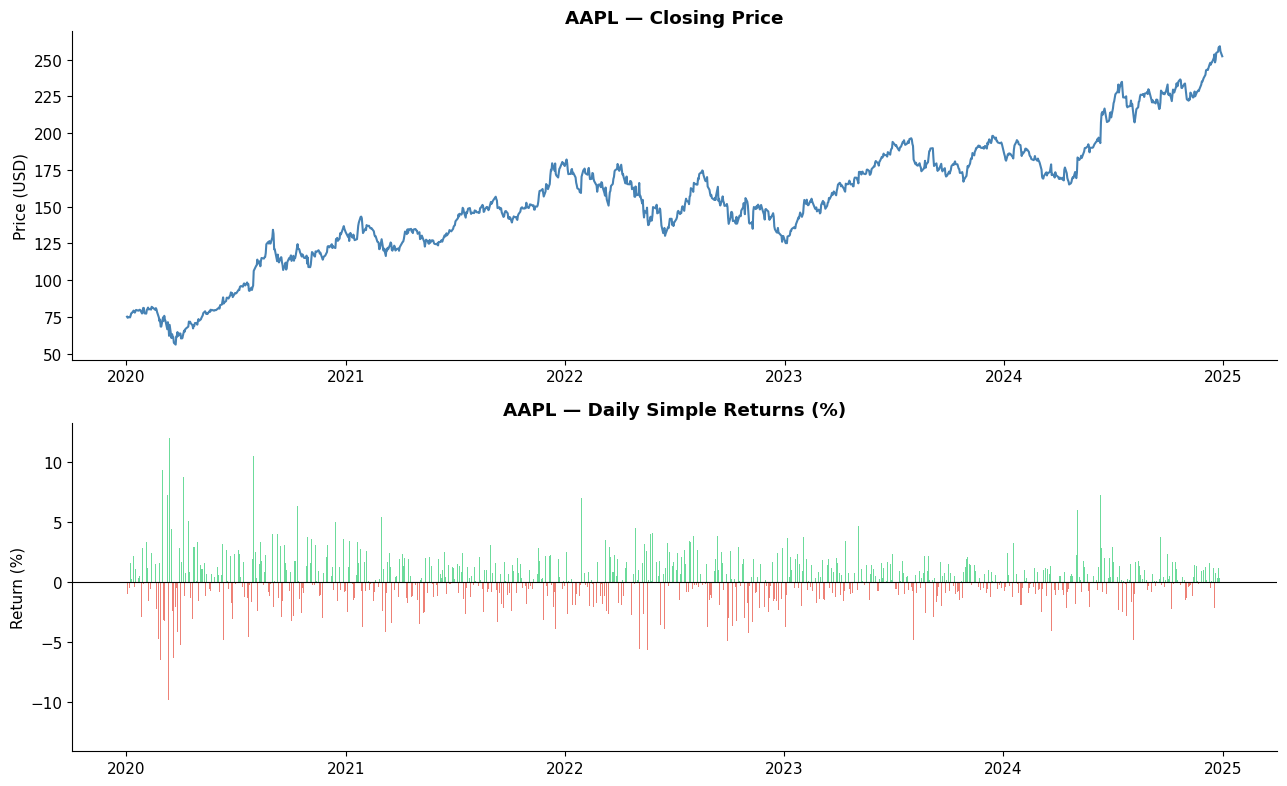


📊 Reading the chart:
  - Most daily returns cluster near 0% — as expected
  - Large spikes (positive/negative) correspond to earnings, news events
  - Worst single day: -12.86% | Best: 11.98%


In [6]:
# ── 1b. Visualize the return series ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Price chart
axes[0].plot(data.index, data['close'], color='steelblue', linewidth=1.5)
axes[0].set_title(f'{TICKER} — Closing Price', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Daily returns
ret = data['simple_return'].dropna()
colors = ['#e74c3c' if r < 0 else '#2ecc71' for r in ret]
axes[1].bar(ret.index, ret * 100, color=colors, width=1.0, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title(f'{TICKER} — Daily Simple Returns (%)', fontweight='bold')
axes[1].set_ylabel('Return (%)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print("\n📊 Reading the chart:")
print("  - Most daily returns cluster near 0% — as expected")
print("  - Large spikes (positive/negative) correspond to earnings, news events")
print(f"  - Worst single day: {ret.min()*100:.2f}% | Best: {ret.max()*100:.2f}%")

---
## 2. Log Returns (Continuously Compounded Returns)

### Theory

The **log return** (or *continuously compounded return*) is defined as:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})
$$

### Why log returns? Three key reasons:

**1. Time additivity** — log returns over multiple periods simply *add up*:  
$r_{total} = r_1 + r_2 + r_3 + \ldots$  
This makes them ideal for aggregating returns across time in quantitative models.

**2. Symmetry** — a +50% gain and a -50% loss are symmetric in log space ($+0.405$ vs $-0.693$), unlike in simple returns where they are asymmetric (you need +100% to recover from -50%).

**3. Statistical properties** — under the standard Black-Scholes assumption, log returns follow a **normal distribution**, which enables many analytical results in options pricing, risk management, and econometric modeling.

<details><summary>Example (Why simple returns fail, log returns work)</summary>

Assume you invest €100 split equally between two assets:

- €50 in Asset A  
- €50 in Asset B  

### Returns

**Day 1**
- A: +10%
- B: +10%

**Day 2**
- A: −10%
- B: −10%

---

### Using simple returns (problem)

Day 1:
- Portfolio: 100 → 110 → **+10%**

Day 2:
- Portfolio: 110 → 99 → **−10%**

Now if we naively add returns:
\[
+10\% - 10\% = 0\%
\]

But actual wealth:
\[
100 \to 99 \quad (\text{−1%})
\]

❌ Simple returns do not aggregate correctly over time.

The issue: each return is applied to a changing base (compounding effect).

---

### Using log returns (works cleanly)

\[
r_1 = \ln(1.10) = 0.0953
\]
\[
r_2 = \ln(0.90) = -0.1053
\]

Now add them:
\[
r_{total} = 0.0953 - 0.1053 = -0.01
\]

Convert back:
\[
e^{-0.01} \approx 0.99
\]

So:
\[
100 \to 99
\]

✔ Log returns correctly capture total performance  
✔ They are additive over time  
✔ No distortion from changing base values

</details>

### Simple vs. Log — practical approximation
For small returns (e.g., daily), $r_t \approx R_t$. The difference grows at larger magnitudes:

$$
r_t \approx R_t - \frac{R_t^2}{2} + \ldots
$$

> 💡 **Trading rule of thumb:** Use **simple returns** for portfolio construction and performance reporting. Use **log returns** for statistical modeling, time-series analysis (GARCH, cointegration), and options pricing.

In [7]:
# ── 2a. Compute log returns ──────────────────────────────────────────────────
data['log_return'] = np.log(data['close'] / data['close'].shift(1))

# Compare simple vs log returns
compare = data[['simple_return', 'log_return']].dropna().head(10)
compare.columns = ['Simple Return', 'Log Return']
compare = compare * 100  # express as %
print("Simple vs Log returns (first 10 days, in %):")
print(compare.round(4))

print("\n→ Note how they're nearly identical for small daily moves")

Simple vs Log returns (first 10 days, in %):
            Simple Return  Log Return
Date                                 
2020-01-03        -0.9722     -0.9770
2020-01-06         0.7968      0.7937
2020-01-07        -0.4703     -0.4714
2020-01-08         1.6086      1.5958
2020-01-09         2.1241      2.1018
2020-01-10         0.2261      0.2258
2020-01-13         2.1364      2.1139
2020-01-14        -1.3503     -1.3595
2020-01-15        -0.4286     -0.4295
2020-01-16         1.2526      1.2449

→ Note how they're nearly identical for small daily moves


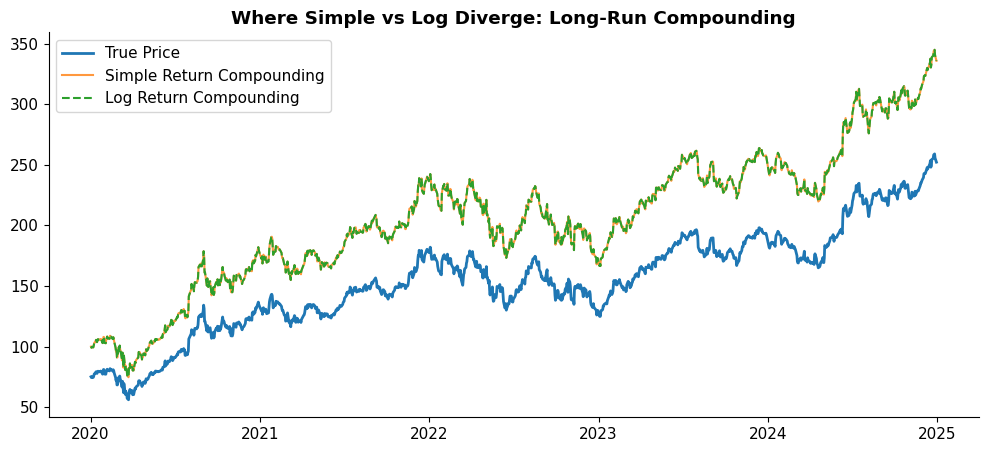

In [14]:
# ── 1. Compute cumulative wealth paths ───────────────────────────────────────

initial = 100

# Simple returns wealth path
wealth_simple = initial * (1 + data['simple_return'].fillna(0)).cumprod()

# Log returns wealth path
wealth_log = initial * np.exp(data['log_return'].fillna(0).cumsum())

# True price (benchmark)
true_price = data['close']

# ── 2. Plot comparison ───────────────────────────────────────────────────────

plt.figure(figsize=(12,5))
plt.plot(true_price, label="True Price", linewidth=2)
plt.plot(wealth_simple, label="Simple Return Compounding", alpha=0.8)
plt.plot(wealth_log, label="Log Return Compounding", linestyle="--")

plt.title("Where Simple vs Log Diverge: Long-Run Compounding", fontweight='bold')
plt.legend()
plt.show()

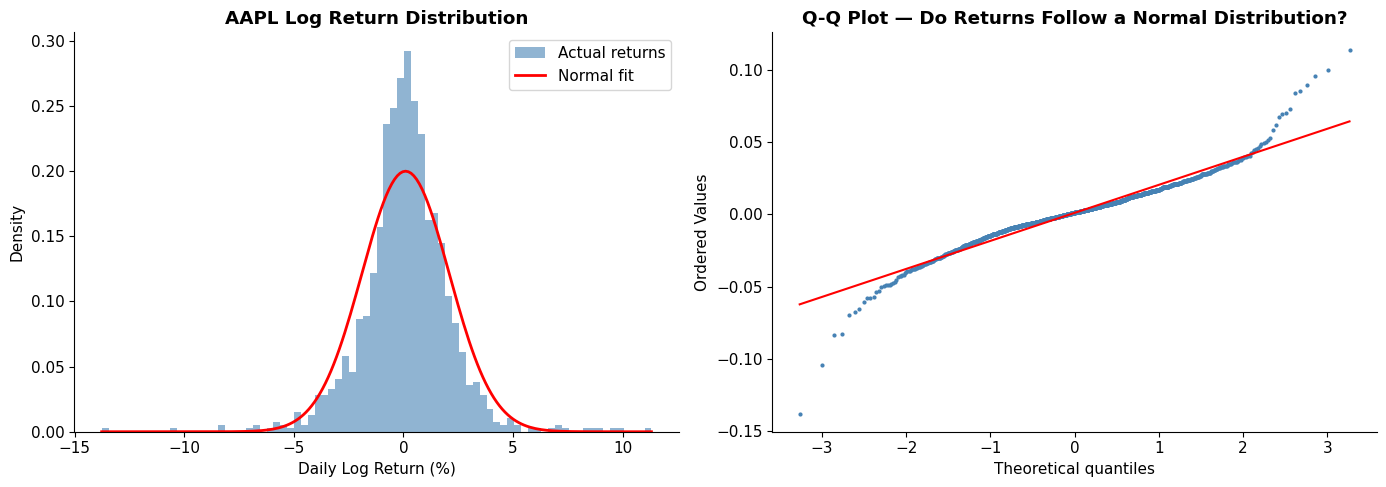


Skewness       : -0.1107   (normal = 0)
Excess Kurtosis: 5.3499   (normal = 0, fat tails > 0)
Jarque-Bera p  : 0.0000e+00

⚠️  Real returns have FAT TAILS (leptokurtosis) — extreme events happen
   more often than a normal distribution would predict.
   This is one of the key risks in quantitative trading models.


In [8]:
# ── 2b. Distribution of log returns ─────────────────────────────────────────
# A key assumption in finance: daily log returns are approximately normally distributed
# Let's visually test this assumption on real data

from scipy import stats

log_ret = data['log_return'].dropna()
mu, sigma = log_ret.mean(), log_ret.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal overlay
axes[0].hist(log_ret * 100, bins=80, density=True, color='steelblue', alpha=0.6, label='Actual returns')
x = np.linspace(log_ret.min(), log_ret.max(), 200)
axes[0].plot(x * 100, stats.norm.pdf(x, mu, sigma) / 100, 'r-', linewidth=2, label='Normal fit')
axes[0].set_title(f'{TICKER} Log Return Distribution', fontweight='bold')
axes[0].set_xlabel('Daily Log Return (%)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q plot
stats.probplot(log_ret, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — Do Returns Follow a Normal Distribution?', fontweight='bold')
axes[1].get_lines()[0].set(color='steelblue', markersize=2)
axes[1].get_lines()[1].set(color='red')

plt.tight_layout()
plt.show()

# Jarque-Bera normality test
jb_stat, jb_p = stats.jarque_bera(log_ret)
skew = stats.skew(log_ret)
kurt = stats.kurtosis(log_ret)  # excess kurtosis (normal = 0)

print(f"\nSkewness       : {skew:.4f}   (normal = 0)")
print(f"Excess Kurtosis: {kurt:.4f}   (normal = 0, fat tails > 0)")
print(f"Jarque-Bera p  : {jb_p:.4e}")
print("\n⚠️  Real returns have FAT TAILS (leptokurtosis) — extreme events happen")
print("   more often than a normal distribution would predict.")
print("   This is one of the key risks in quantitative trading models.")

---
## 3. Dividend-Adjusted Returns

### Theory

A stock investor earns returns from **two sources**:
1. **Capital gain** — the change in price
2. **Dividend income** — cash payments by the company

The **total return** (dividend-adjusted) is:

$$
R_t = \frac{P_t + Div_t - P_{t-1}}{P_{t-1}} = \underbrace{\frac{P_t - P_{t-1}}{P_{t-1}}}_{\text{price return}} + \underbrace{\frac{Div_t}{P_{t-1}}}_{\text{dividend yield}}
$$

This matches your lecture notes exactly:
$$
\text{Retorno} = \frac{P_F + Div - P_I}{P_I}
$$

### Why this matters for trading

**Ignoring dividends distorts everything.** For high-dividend-paying stocks (utilities, REITs, mature blue-chips), the dividend component can represent 3-6% annually — this is not negligible. A stock that appears flat on a price chart might have delivered a solid total return once dividends are included.

> ⚠️ **Common mistake:** Many retail traders compare price charts without adjusting for dividends, which leads to systematically underestimating the value of income-generating assets.

> 💡 `yfinance` provides an **`Adj Close`** column which incorporates historical dividends and splits into the price series — this is the correct series to use for backtesting.

In [ ]:
# ── 3a. Manually compute dividend-adjusted return ───────────────────────────
# Formula: R_t = (P_t + Div_t - P_{t-1}) / P_{t-1}

data['div_adj_return'] = (data['close'] + data['dividends'] - data['close'].shift(1)) / data['close'].shift(1)

# Show dividend payment dates
div_days = data[data['dividends'] > 0][['close', 'dividends', 'simple_return', 'div_adj_return']]
div_days.columns = ['Price', 'Dividend', 'Price Return', 'Total Return']

print(f"Apple dividend payment dates in {START[:4]}–{END[:4]}:")
print((div_days * 100).round(4).to_string())
print("\n→ On ex-dividend dates, total return > price return by the dividend yield")

In [ ]:
# ── 3b. Cumulative wealth comparison: price-only vs. total return ────────────
# Starting with $1 invested — how does ignoring dividends distort the picture?

wealth_price = (1 + data['simple_return'].fillna(0)).cumprod()
wealth_total = (1 + data['div_adj_return'].fillna(0)).cumprod()

plt.figure(figsize=(13, 5))
plt.plot(data.index, wealth_total, label='Total Return (price + dividends)', color='#2ecc71', linewidth=2)
plt.plot(data.index, wealth_price, label='Price Return only', color='steelblue', linewidth=2, linestyle='--')
plt.fill_between(data.index, wealth_price, wealth_total, alpha=0.15, color='green', label='Dividend contribution')
plt.title(f'{TICKER} — Cumulative Wealth: $1 Invested (Price vs. Total Return)', fontweight='bold')
plt.ylabel('Portfolio Value (starting at $1)')
plt.legend()
plt.tight_layout()
plt.show()

total_gain_price = wealth_price.iloc[-1] - 1
total_gain_div   = wealth_total.iloc[-1] - 1
print(f"\nCumulative return (price only)     : {total_gain_price*100:.1f}%")
print(f"Cumulative return (with dividends) : {total_gain_div*100:.1f}%")
print(f"Dividend contribution              : {(total_gain_div - total_gain_price)*100:.1f} percentage points")

---
## 4. Annualizing Returns

### Theory

Investments are held over different time horizons — you need a common scale for comparison. **Annualization** converts any holding period return to an equivalent annual rate.

#### Method A — Arithmetic annualization (your notes: "promedio aritmético")
Simply scale the average period return by the number of periods per year:

$$
\bar{R}_{annual} = \bar{R}_{daily} \times 252
$$

*(252 = typical number of trading days per year)*

#### Method B — Geometric annualization (your notes: "interés compuesto")
Chain-link the periodic returns — this gives you the actual compound growth rate:

$$
R_{annual}^{geo} = (1 + R_1)(1 + R_2)\cdots(1 + R_n)^{252/n} - 1
$$

Or equivalently using the holding period return:

$$
R_{annual}^{geo} = \left(\frac{P_T}{P_0}\right)^{252/T} - 1
$$

### Key insight from your notes
> *"El promedio aritmético es mayor que el rendimiento anual compuesto del período"*  
> (The arithmetic mean is always ≥ the geometric mean — Jensen's inequality)

This means:
- **Arithmetic mean** → use for estimating *expected future* return (forward-looking)
- **Geometric mean (CAGR)** → use for measuring *actual past* performance (backward-looking)

> 💡 **CAGR (Compound Annual Growth Rate)** is the standard metric used by fund managers, financial news, and investment reports to report historical performance.

In [ ]:
# ── 4a. Annualize daily returns ──────────────────────────────────────────────
TRADING_DAYS = 252

ret = data['simple_return'].dropna()

# Arithmetic annualization
ann_arithmetic = ret.mean() * TRADING_DAYS

# Geometric annualization (CAGR)
n_days = len(ret)
n_years = n_days / TRADING_DAYS
total_return = (1 + ret).prod()  # compound all daily returns
ann_geometric = total_return ** (1 / n_years) - 1

# Annualized volatility
ann_volatility = ret.std() * np.sqrt(TRADING_DAYS)

print(f"{'='*45}")
print(f"  {TICKER} Annualized Return Summary ({START[:4]}–{END[:4]})")
print(f"{'='*45}")
print(f"  Arithmetic annual return : {ann_arithmetic*100:>8.2f}%")
print(f"  Geometric annual return  : {ann_geometric*100:>8.2f}%  ← CAGR (actual compound)")
print(f"  Difference (Arith - Geo) : {(ann_arithmetic - ann_geometric)*100:>8.2f}%  ← always ≥ 0")
print(f"  Annualized volatility    : {ann_volatility*100:>8.2f}%")
print(f"{'='*45}")
print("\nThis confirms your lecture note: arithmetic > geometric (Jensen's inequality)")

In [ ]:
# ── 4b. Rolling annual return — how returns change over time ─────────────────
# A 252-day rolling window shows "if you held for 1 year ending on this date,
# what was your geometric return?"

rolling_annual = (1 + data['simple_return']).rolling(TRADING_DAYS).apply(np.prod, raw=True) - 1

plt.figure(figsize=(13, 5))
plt.plot(data.index, rolling_annual * 100, color='steelblue', linewidth=1.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(ann_geometric * 100, color='orange', linewidth=1.5, linestyle='--',
            label=f'Overall CAGR: {ann_geometric*100:.1f}%')
plt.fill_between(data.index, rolling_annual * 100, 0,
                 where=(rolling_annual > 0), alpha=0.2, color='green')
plt.fill_between(data.index, rolling_annual * 100, 0,
                 where=(rolling_annual < 0), alpha=0.2, color='red')
plt.title(f'{TICKER} — Rolling 1-Year Geometric Return (%)', fontweight='bold')
plt.ylabel('1-Year Return (%)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n📊 Key takeaway for traders:")
print("  - Even for a strong long-term performer like AAPL, there are sustained")
print("    periods of negative 1-year returns.")
print("  - The CAGR (orange line) is the geometric average over the full period.")

---
## 5. Compound Interest — The Engine of Long-Term Returns

### Theory

The **compound interest formula** (your notes: *"Interés Compuesto"*) tells us the future value of an investment:

$$
FV = PV \times (1 + R_1)(1 + R_2) \cdots (1 + R_T) = PV \times \prod_{t=1}^{T}(1 + R_t)
$$

For a **constant** annual rate $r$ over $n$ years:

$$
FV = PV \times (1 + r)^n
$$

Your notes demonstrate this: starting with $\$1$, three periods with returns of $-0.18\%$, $+11.86\%$, $-2.45\%$ compound to:

$$
FV = \$1 \times (1 - 0.0018)(1 + 0.1186)(1 - 0.0245) = \$1.0892 \Rightarrow 8.92\%\text{ annual return}
$$

### The crucial asymmetry: losses hurt more than gains help

| Event | Simple arithmetic | Compound reality |
|-------|-------------------|------------------|
| +50% then -50% | Average = 0% | $(1.5)(0.5) = 0.75$ → **-25% loss!** |
| +10% per year for 10 years | 100% total | $(1.1)^{10} = 2.59$ → **+159% total** |

> 💡 **This is why risk management is not optional.** A single -50% drawdown requires a subsequent +100% gain just to break even. Protecting capital is as important as generating returns.

In [ ]:
# ── 5a. Replicating your notes' compound return calculation ──────────────────
r1, r2, r3 = -0.0018, 0.1186, -0.0245  # your notes' three period returns

FV = 1 * (1 + r1) * (1 + r2) * (1 + r3)
total_return_3periods = FV - 1

# Equivalent annual rate for 8 months (~0.67 years)
n_years = 8/12
ann_equiv = (FV) ** (1/n_years) - 1

print("Replicating your lecture notes' example:")
print(f"  r1 = {r1*100:.2f}%,  r2 = {r2*100:.2f}%,  r3 = {r3*100:.2f}%")
print(f"  FV of $1 = ${FV:.4f}")
print(f"  8-month compound return = {total_return_3periods*100:.2f}%")
print(f"  Annualized (8 months)   = {ann_equiv*100:.2f}%  (your notes: 8.92%)")

In [ ]:
# ── 5b. The power of compounding — $10,000 invested in AAPL ─────────────────
INITIAL_INVESTMENT = 10_000

wealth = INITIAL_INVESTMENT * (1 + data['simple_return'].fillna(0)).cumprod()

final_value = wealth.iloc[-1]
cagr = (final_value / INITIAL_INVESTMENT) ** (1 / n_years) - 1  # reusing n_years from above
n_years_actual = len(data) / TRADING_DAYS
cagr = (final_value / INITIAL_INVESTMENT) ** (1 / n_years_actual) - 1

plt.figure(figsize=(13, 5))
plt.plot(data.index, wealth, color='steelblue', linewidth=2)
plt.fill_between(data.index, INITIAL_INVESTMENT, wealth,
                 where=(wealth >= INITIAL_INVESTMENT), alpha=0.15, color='green')
plt.fill_between(data.index, INITIAL_INVESTMENT, wealth,
                 where=(wealth < INITIAL_INVESTMENT), alpha=0.15, color='red')
plt.axhline(INITIAL_INVESTMENT, color='black', linewidth=0.8, linestyle='--', label='Initial $10,000')
plt.title(f'${INITIAL_INVESTMENT:,} Invested in {TICKER} — Compound Growth', fontweight='bold')
plt.ylabel('Portfolio Value (USD)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n  Initial investment : ${INITIAL_INVESTMENT:,.0f}")
print(f"  Final value        : ${final_value:,.0f}")
print(f"  Total return       : {(final_value/INITIAL_INVESTMENT - 1)*100:.1f}%")
print(f"  CAGR               : {cagr*100:.2f}% per year")
print(f"  Period             : {n_years_actual:.1f} years")

In [ ]:
# ── 5c. The asymmetry of gains and losses ───────────────────────────────────
# One of the most important concepts for risk management

losses = np.arange(0.05, 0.95, 0.05)  # 5% to 90% loss
required_gain = 1 / (1 - losses) - 1   # gain needed to recover

plt.figure(figsize=(10, 5))
plt.plot(losses * 100, required_gain * 100, color='crimson', linewidth=2.5)
plt.fill_between(losses * 100, losses * 100, required_gain * 100, alpha=0.15, color='crimson')
plt.plot(losses * 100, losses * 100, '--', color='gray', linewidth=1.5, label='If gains = losses (false!)')

# Annotate key points
for loss_pct in [25, 50, 75]:
    rg = (1 / (1 - loss_pct/100) - 1) * 100
    plt.annotate(f'-{loss_pct}% → need +{rg:.0f}%',
                 xy=(loss_pct, rg), xytext=(loss_pct + 3, rg - 10),
                 fontsize=9, color='crimson')

plt.title('The Asymmetry of Losses — Required Gain to Break Even', fontweight='bold')
plt.xlabel('Loss (%)')
plt.ylabel('Required Recovery Gain (%)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n⚠️  This is why professional traders obsess over DRAWDOWN control:")
print("   A -50% loss requires a +100% gain just to get back to where you started.")
print("   Risk management is not optional — it IS the strategy.")

---
## 6. Putting It All Together — Multi-Asset Return Comparison

A trader always evaluates assets **relative to each other**. Let's apply everything from this module to compare multiple assets simultaneously — a typical first step in building a watchlist or portfolio.

In [ ]:
# ── 6a. Download multiple assets ─────────────────────────────────────────────
# Mix of equity, a benchmark index, and a bond ETF

TICKERS = {
    'AAPL':  'Apple (Tech)',
    'MSFT':  'Microsoft (Tech)',
    'JPM':   'JPMorgan (Finance)',
    'SPY':   'S&P 500 ETF (Benchmark)',
    'TLT':   '20-Year Treasury ETF (Bonds)',
}

prices = yf.download(
    list(TICKERS.keys()),
    start=START, end=END,
    auto_adjust=True, progress=False
)['Close']

prices.columns = [TICKERS[t] for t in prices.columns]
print(f"Downloaded {len(prices)} trading days for {len(prices.columns)} assets")
prices.tail(3)

In [ ]:
# ── 6b. Compute returns summary table ───────────────────────────────────────
daily_returns = prices.pct_change().dropna()
log_returns   = np.log(prices / prices.shift(1)).dropna()

n_yrs = len(daily_returns) / TRADING_DAYS

summary = pd.DataFrame(index=prices.columns)
summary['CAGR (%)']         = ((1 + daily_returns).prod() ** (1/n_yrs) - 1) * 100
summary['Ann. Arith. (%)']  = daily_returns.mean() * TRADING_DAYS * 100
summary['Ann. Volatility (%)'] = daily_returns.std() * np.sqrt(TRADING_DAYS) * 100
summary['Best Day (%)']     = daily_returns.max() * 100
summary['Worst Day (%)']    = daily_returns.min() * 100
summary['Sharpe (approx.)'] = summary['CAGR (%)'] / summary['Ann. Volatility (%)']

print("Multi-Asset Return Summary:")
print(summary.round(2).to_string())
print("\n* Sharpe here is return/risk (no risk-free subtraction) — a rough ranking only")

In [ ]:
# ── 6c. Normalized price chart — the trader's standard view ─────────────────
# Normalize to 100 at start so all assets are visually comparable

normalized = prices / prices.iloc[0] * 100

colors = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad', '#c0392b']

plt.figure(figsize=(13, 6))
for col, color in zip(normalized.columns, colors):
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1.8, color=color)

plt.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('Normalized Performance (Base = 100 on Start Date)', fontweight='bold')
plt.ylabel('Indexed Value (start = 100)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("\n📊 Reading this chart:")
print("  - All assets start at 100. A value of 200 means +100% from start date.")
print("  - This is the standard chart type used in financial analysis to compare")
print("    assets with very different absolute price levels.")

---
## 7. Module Summary & Key Takeaways

| Concept | Formula | When to use in trading |
|---|---|---|
| Simple return | $R_t = (P_t - P_{t-1})/P_{t-1}$ | Portfolio construction, performance reporting |
| Log return | $r_t = \ln(P_t/P_{t-1})$ | Statistical modeling, time-series analysis, options |
| Dividend-adjusted return | $R_t = (P_t + Div_t - P_{t-1})/P_{t-1}$ | True investor return, backtesting |
| Arithmetic annualization | $\bar{R} \times 252$ | Expected future return estimation |
| CAGR (geometric) | $(P_T/P_0)^{1/n} - 1$ | Historical performance measurement |
| Compound growth | $FV = PV \times \prod(1+R_t)$ | Long-term wealth projection |

### 🔑 Three Rules to Carry Into Your Trading

1. **Always use dividend-adjusted prices** (`Adj Close` or `auto_adjust=True`) when backtesting. Raw price charts omit a significant component of real returns.

2. **Arithmetic > Geometric** — the gap between them grows with volatility. High-volatility assets need higher average returns just to produce the same compound growth as a lower-volatility alternative.

3. **Asymmetry of losses** — a -50% drawdown requires +100% to recover. This is the fundamental reason professional traders focus as much on loss prevention as on return generation.

---

### ➡️ Next: Module 1.2 — Asset Classes & Benchmarks
We will compare T-bills, government bonds, corporate bonds, and equities using `yfinance` — exploring the empirical risk-return tradeoff across asset classes over long historical periods.